In [1]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'savefig.facecolor': 'none',
    'text.color': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#e0e0e0',
    'ytick.color': '#e0e0e0',
    'axes.edgecolor': '#e0e0e0'
})


# Title: insert title here

#### **insert subheader**

In [2]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pandas as pd
# Load data from nflverse (contains wAV)
url = 'https://github.com/nflverse/nflverse-data/releases/download/draft_picks/draft_picks.csv'
draft_df = pd.read_csv(url)

# Filter QBs and rename columns to match the legacy notebook format
qbs = draft_df[draft_df['position'] == 'QB'].copy()
qbs = qbs[['season', 'round', 'pick', 'team', 'pfr_player_name', 'age', 'to', 'allpro', 'probowls', 'seasons_started', 'w_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts', 'pass_yards', 'pass_tds', 'pass_ints']]
qbs.columns = ['Year', 'Round', 'Pick', 'Tm', 'Player', 'Age', 'To', 'AP1', 'PB', 'St', 'wAV', 'DrAV', 'G', 'Cmp', 'Att', 'Yds', 'TD', 'Int']

# Convert necessary columns to numeric
numeric_cols = ['Pick', 'wAV', 'Round', 'Year', 'To']
for col in numeric_cols:
    qbs[col] = pd.to_numeric(qbs[col], errors='coerce')
qbs = qbs.dropna(subset=['Pick', 'wAV'])
qbs['Pick'] = qbs['Pick'].astype(int)
qbs['wAV'] = qbs['wAV'].astype(float)

qbs['wAV/Yr'] = qbs['wAV'] / (qbs['To'] - qbs['Year'])
qbs.head()


,Year,Round,Pick,Tm,Player,Age,To,AP1,PB,St,wAV,DrAV,G,Cmp,Att,Yds,TD,Int,wAV/Yr
14,1980,1,15,OAK,Marc Wilson,23.0,1990.0,0,0,5,36.0,33.0,126.0,1085.0,2081.0,14391.0,86.0,102.0,3.600000
27,1980,1,28,PIT,Mark Malone,21.0,1989.0,0,0,5,27.0,25.0,73.0,839.0,1648.0,10175.0,60.0,81.0,3.000000
84,1980,4,85,DET,Eric Hipple,22.0,1989.0,0,0,4,38.0,38.0,102.0,830.0,1546.0,10711.0,55.0,70.0,4.222222
88,1980,4,89,STL,Rusty Lisch,23.0,1984.0,0,0,0,2.0,0.0,30.0,55.0,115.0,547.0,1.0,11.0,0.500000
100,1980,4,101,SDG,Ed Luther,23.0,1984.0,0,0,0,7.0,7.0,61.0,245.0,460.0,3187.0,12.0,23.0,1.750000


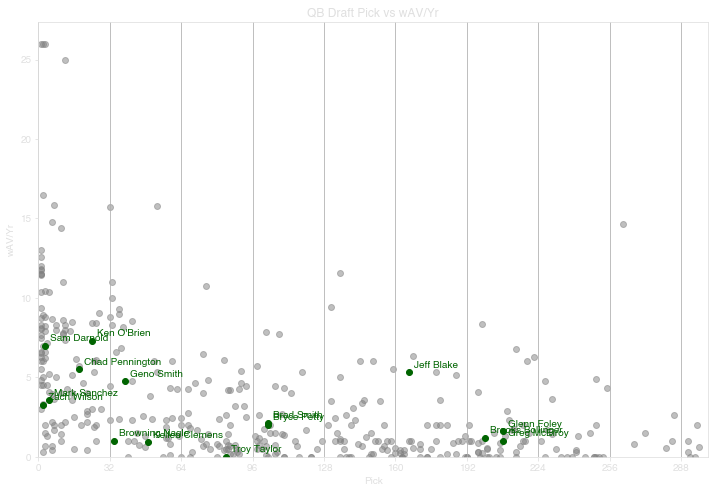

In [4]:
# Set font to Helvetica
plt.rcParams['font.family'] = 'Helvetica'

# Plot
plt.figure(figsize=(12, 8))

# Separate NYJ and other teams
nyj_mask = qbs['Tm'] == 'NYJ'
other_mask = qbs['Tm'] != 'NYJ'

# Plot other teams in gray
plt.scatter(qbs.loc[other_mask, 'Pick'], qbs.loc[other_mask, 'wAV/Yr'], 
            alpha=0.5, color='gray', label='Other Teams')

# Plot NYJ in green
plt.scatter(qbs.loc[nyj_mask, 'Pick'], qbs.loc[nyj_mask, 'wAV/Yr'], 
            alpha=1, color='darkgreen', label='NYJ')

# Label all NYJ points
nyj_qbs = qbs[nyj_mask]
for idx, row in nyj_qbs.iterrows():
    plt.annotate(row['Player'], 
                (row['Pick'], row['wAV/Yr']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, alpha=1, fontfamily='Helvetica', color='darkgreen')

# Find and label the highest wAV/Yr points (top 10), excluding NYJ since they're already labeled
top_qbs = qbs[~nyj_mask].nlargest(10, 'wAV/Yr')
for idx, row in top_qbs.iterrows():
    plt.annotate(row['Player'], 
                (row['Pick'], row['wAV/Yr']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, alpha=1, fontfamily='Helvetica')

# Add horizontal line at y=0
plt.axhline(y=0, color='black', linewidth=1)

plt.xlabel('Pick')
plt.ylabel('wAV/Yr')
plt.title('QB Draft Pick vs wAV/Yr')
plt.grid(True, which='both', axis='x')
plt.xticks(range(0, 301, 32))
plt.xlim(left=0, right=300)
plt.ylim(bottom=0)
plt.savefig('../../public/assets/images/2025-11-09-QB_Draft/qb_drafts_all.png', bbox_inches='tight')
plt.show()

In [5]:
first_rounders = qbs[qbs['Round'] == 1]

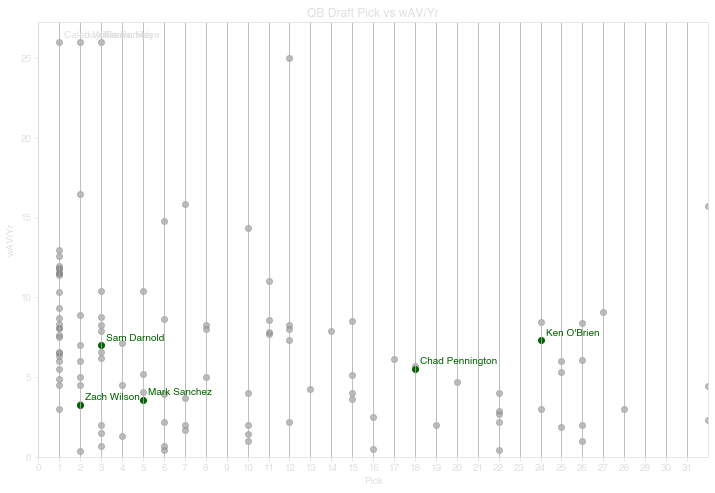

In [6]:
# Plot
plt.figure(figsize=(12, 8))

# Separate NYJ and other teams
nyj_mask_1 = first_rounders['Tm'] == 'NYJ'
other_mask_1 = first_rounders['Tm'] != 'NYJ'

# Plot other teams in gray
plt.scatter(first_rounders.loc[other_mask_1, 'Pick'], first_rounders.loc[other_mask_1, 'wAV/Yr'], 
            alpha=0.5, color='gray', label='Other Teams')

# Plot NYJ in green
plt.scatter(first_rounders.loc[nyj_mask_1, 'Pick'], first_rounders.loc[nyj_mask_1, 'wAV/Yr'], 
            alpha=1, color='darkgreen', label='NYJ')

# Label all NYJ points
nyj_firsts = first_rounders[nyj_mask_1]
for idx, row in nyj_firsts.iterrows():
    plt.annotate(row['Player'], 
                (row['Pick'], row['wAV/Yr']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, alpha=1, fontfamily='Helvetica', color='darkgreen')

# Find and label the highest wAV/Yr points (top 10), excluding NYJ since they're already labeled
top_qbs_1 = first_rounders[~nyj_mask_1].nlargest(5, 'wAV/Yr')
for idx, row in top_qbs_1.iterrows():
    plt.annotate(row['Player'], 
                (row['Pick'], row['wAV/Yr']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, alpha=1, fontfamily='Helvetica')

# Add horizontal line at y=0
plt.axhline(y=0, color='black', linewidth=1)

plt.xlabel('Pick')
plt.ylabel('wAV/Yr')
plt.title('QB Draft Pick vs wAV/Yr')
plt.grid(True, which='both', axis='x')
plt.xticks(range(0, 32, 1))
plt.xlim(left=0, right=32)
plt.ylim(bottom=0)
plt.savefig('../../public/assets/images/2025-11-09-QB_Draft/qb_drafts_1st.png', bbox_inches='tight')
plt.show()